# Classificador de Qualidade de Lances de Xadrez

**Disciplina:** Paradigmas de Aprendizagem de Máquina  
**Objetivo:** Classificar lances de xadrez como **bom** ou **ruim** para jogadores de nível intermediário (rating 1200–1500 Chess.com / 1400–1700 Lichess).

## Motivação

Jogadores intermediários cometem erros frequentes no meio-jogo — peças penduradas, trocas desfavoráveis, descuido com a segurança do rei. Um classificador supervisionado que identifique padrões posicionais associados a lances ruins pode servir como ferramenta de estudo, destacando situações típicas em que esses jogadores erram.

## Abordagem

1. **Dados:** partidas reais do [Lichess](https://lichess.org) (CC0), filtradas por faixa de rating e controle de tempo.
2. **Rotulagem:** avaliação posicional via **Stockfish** (depth 15). Lance "bom" se perde ≤ 50 centipawns; "ruim" se perde ≥ 150 centipawns. Zona cinzenta descartada.
3. **Features:** 33 features posicionais extraídas com `python-chess` (material, mobilidade, segurança do rei, estrutura de peões, etc.).
4. **Modelos:** Decision Tree (interpretável, obrigatório) + Random Forest (ensemble, para comparação).
5. **Métricas:** foco em recall e F1 da classe "ruim" — detectar erros é o objetivo principal.

In [1]:
import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import export_text, plot_tree

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

DATA_DIR = Path("..") / "data"

print("Setup OK")

Setup OK


---

## 2. Coleta e Descrição dos Dados

### Fonte

Os dados vêm da **Lichess open database** ([database.lichess.org](https://database.lichess.org)), disponível sob licença **CC0** (domínio público).

- **Ficheiro:** `lichess_db_standard_rated_2015-01.pgn.zst` (~272 MiB comprimido)
- **Formato:** PGN comprimido com Zstandard, processado em streaming sem carregar na RAM

### Filtros aplicados

| Filtro | Critério |
|--------|----------|
| **Rating** | Ambos os jogadores entre 1400–1700 (Lichess) |
| **Controle de tempo** | Blitz/Rapid: 180+0, 180+2, 300+0, 300+3, 600+0, 600+5 |
| **Término** | Apenas partidas terminadas normalmente (mate/resignação) |
| **Variante** | Standard (sem Chess960, etc.) |
| **Fase do jogo** | Lances 8 a 40 (meio-jogo) |
| **Amostragem** | Taxa de 10%, seed=42 |

In [2]:
df_filtered = pd.read_csv(DATA_DIR / "filtered" / "moves_filtered.csv")

print(f"Lances filtrados (meio-jogo): {len(df_filtered):,}")
print(f"Partidas únicas: {df_filtered['game_site'].nunique():,}")
print(f"\nColunas: {list(df_filtered.columns)}")
print(f"\nPrimeiras linhas:")
df_filtered.head()

Lances filtrados (meio-jogo): 136,620
Partidas únicas: 2,911

Colunas: ['game_id', 'game_site', 'white_elo', 'black_elo', 'time_control', 'result', 'move_number', 'color', 'fen_before', 'move_uci', 'move_san']

Primeiras linhas:


,game_id,game_site,white_elo,black_elo,time_control,result,move_number,color,fen_before,move_uci,move_san
0,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,white,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2NBBN2/PPP2P...,d3e2,Be2
1,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,black,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1B...,g8e7,Ne7
2,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,white,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1BP...,a2a3,a3
3,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,black,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/P1N1BN2/1PP1B...,b4a6,Na6
4,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,10,white,r2qk2r/pbppnpbp/np4p1/3Pp3/4P3/P1N1BN2/1PP1BPP...,d1d2,Qd2


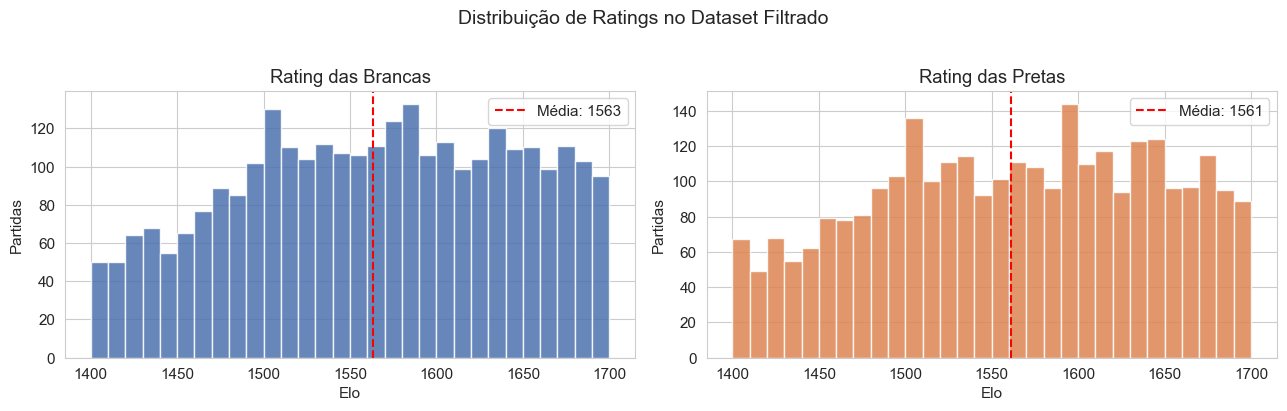

Elo médio geral: 1562


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title, color in [
    (axes[0], "white_elo", "Rating das Brancas", "#4C72B0"),
    (axes[1], "black_elo", "Rating das Pretas", "#DD8452"),
]:
    elos = df_filtered.groupby("game_site")[col].first()
    ax.hist(elos, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel("Elo")
    ax.set_ylabel("Partidas")
    ax.set_title(title)
    ax.axvline(elos.mean(), color="red", linestyle="--", label=f"Média: {elos.mean():.0f}")
    ax.legend()

plt.suptitle("Distribuição de Ratings no Dataset Filtrado", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Elo médio geral: {(df_filtered.groupby('game_site')['white_elo'].first().mean() + df_filtered.groupby('game_site')['black_elo'].first().mean()) / 2:.0f}")

---

## 3. Rotulagem via Stockfish

### Conceito: Centipawn Loss (delta)

Para cada lance, a qualidade é medida pela **perda de avaliação** que ele causa:

$$\text{delta} = \text{eval\_depois} - \text{eval\_antes}$$

onde ambas as avaliações são do ponto de vista do jogador que fez o lance (via `score.relative` do `python-chess`).

### Limiares de classificação

| Classe | Condição | Significado |
|--------|----------|-------------|
| **Bom** | delta ≥ −50 cp | Lance não piora significativamente (≤ 0.5 peão) |
| **Descartado** | −150 < delta < −50 | Zona cinzenta — imprecisão intermediária |
| **Ruim** | delta ≤ −150 cp | Erro grave — perde ≥ 1.5 peão |

A **zona cinzenta** é descartada para reduzir ruído nos rótulos: lances que perdem entre 0.5 e 1.5 peão são ambíguos — classificá-los como bom ou ruim introduziria incerteza.

### Configuração do Stockfish

- **Engine:** Stockfish 18
- **Profundidade:** 15 (suficiente para detectar táticas de 3–4 lances)
- **Workers:** 6 paralelos com caching de avaliações consecutivas
- **Tempo:** ~174 minutos em Apple M4

In [4]:
df_scored = pd.read_csv(DATA_DIR / "labeled" / "moves_all_scored.csv")
df_labeled = pd.read_csv(DATA_DIR / "labeled" / "moves_labeled.csv")

print(f"Total de lances avaliados: {len(df_scored):,}")
print(f"Lances rotulados (bom + ruim): {len(df_labeled):,}")
print(f"Lances descartados (zona cinzenta): {len(df_scored) - len(df_labeled):,}")
print(f"\nDistribuição de rótulos:")
print(df_labeled["label"].value_counts().to_string())

n_bom = (df_labeled["label"] == "bom").sum()
n_ruim = (df_labeled["label"] == "ruim").sum()
print(f"\nRatio bom:ruim = {n_bom / n_ruim:.2f}:1")

Total de lances avaliados: 136,620
Lances rotulados (bom + ruim): 109,290
Lances descartados (zona cinzenta): 27,330

Distribuição de rótulos:
label
bom     92197
ruim    17093

Ratio bom:ruim = 5.39:1


/var/folders/r8/bqlpr1gs2574p3kyfyqdz_940000gn/T/ipykernel_38324/1975732513.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bom_delta, ruim_delta], labels=["Bom", "Ruim"],


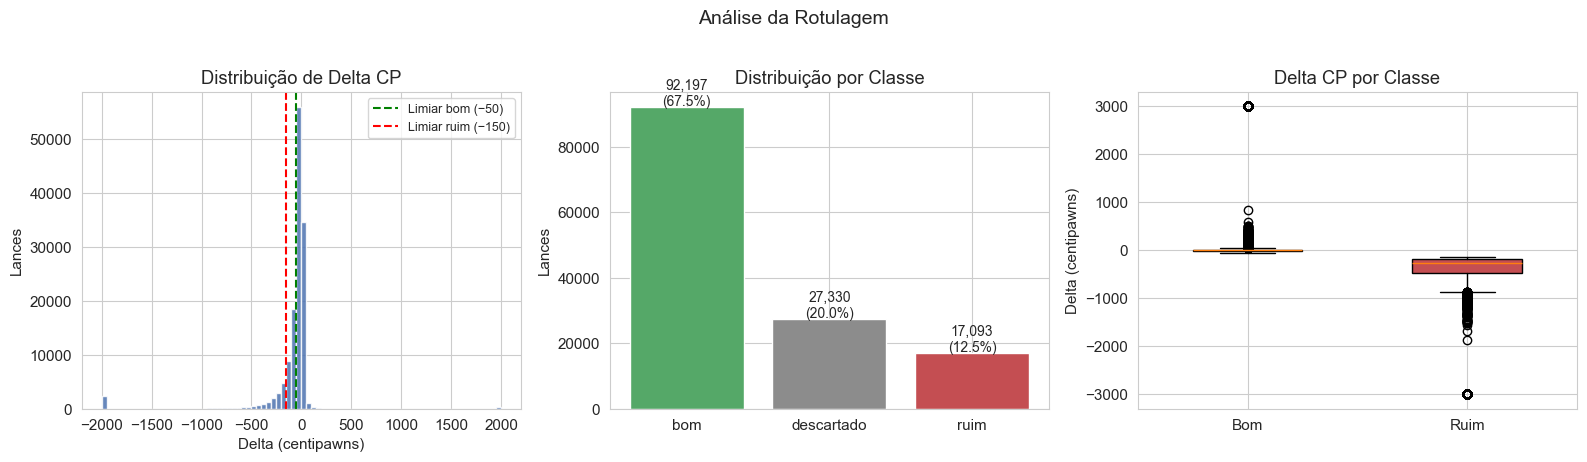

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histograma de delta_cp (todos os lances)
ax = axes[0]
deltas = df_scored["delta_cp"].clip(-2000, 2000)
ax.hist(deltas, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(-50, color="green", linestyle="--", linewidth=1.5, label="Limiar bom (−50)")
ax.axvline(-150, color="red", linestyle="--", linewidth=1.5, label="Limiar ruim (−150)")
ax.set_xlabel("Delta (centipawns)")
ax.set_ylabel("Lances")
ax.set_title("Distribuição de Delta CP")
ax.legend(fontsize=9)

# Distribuição por classe
ax = axes[1]
counts = df_scored["label"].value_counts()
colors = {"bom": "#55A868", "ruim": "#C44E52", "descartado": "#8C8C8C"}
order = ["bom", "descartado", "ruim"] if "descartado" in counts.index else ["bom", "ruim"]
bars = ax.bar(order, [counts.get(c, 0) for c in order],
              color=[colors.get(c, "gray") for c in order], edgecolor="white")
for bar, c in zip(bars, order):
    val = counts.get(c, 0)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}\n({val/len(df_scored)*100:.1f}%)", ha="center", fontsize=10)
ax.set_ylabel("Lances")
ax.set_title("Distribuição por Classe")

# Boxplot de delta por classe (só bom e ruim)
ax = axes[2]
bom_delta = df_labeled[df_labeled["label"] == "bom"]["delta_cp"].clip(-3000, 3000)
ruim_delta = df_labeled[df_labeled["label"] == "ruim"]["delta_cp"].clip(-3000, 3000)
bp = ax.boxplot([bom_delta, ruim_delta], labels=["Bom", "Ruim"],
                patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#55A868")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Delta (centipawns)")
ax.set_title("Delta CP por Classe")

plt.suptitle("Análise da Rotulagem", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Engenharia de Features

Foram extraídas **33 features** organizadas em 7 grupos, todas numéricas e computadas a partir do estado do tabuleiro antes de cada lance usando `python-chess`:

| Grupo | Qtd. | Features |
|-------|------|----------|
| **Material** | 11 | Contagem de peças por tipo/cor + diferença material ponderada |
| **Mobilidade** | 3 | Lances legais (jogador/adversário) + diferença |
| **Segurança do rei** | 4 | Roque realizado, direito a roque, escudo de peões |
| **Estrutura de peões** | 4 | Peões dobrados, isolados, passados |
| **Controle do centro** | 3 | Ataques e ocupação das casas d4/d5/e4/e5 |
| **Características do lance** | 6 | Captura, xeque, promoção, peça movida, destino |
| **Contexto** | 2 | Número do lance, cor do jogador |

Nenhuma feature usa one-hot encoding de casas individuais (64 casas gerariam esparsidade excessiva sem ganho para árvores de decisão). Todas são compatíveis diretamente com scikit-learn sem necessidade de normalização para modelos baseados em árvore.

In [6]:
df_features = pd.read_csv(DATA_DIR / "features" / "features.csv")

feature_cols = [c for c in df_features.columns if c != "label"]
print(f"Linhas: {len(df_features):,}")
print(f"Features: {len(feature_cols)}")
print(f"Valores nulos: {df_features[feature_cols].isnull().sum().sum()}")
print(f"\nDistribuição do label:")
print(df_features["label"].value_counts().to_string())
print(f"\nEstatísticas descritivas:")
df_features[feature_cols].describe().round(2)

Linhas: 109,290
Features: 33
Valores nulos: 0

Distribuição do label:
label
bom     92197
ruim    17093

Estatísticas descritivas:


,white_pawns,white_knights,white_bishops,white_rooks,white_queens,black_pawns,black_knights,black_bishops,black_rooks,black_queens,...,opponent_center_control,player_center_occupation,is_capture,is_check,is_promotion,moved_piece,move_to_center,move_to_extended_center,move_number,is_white
count,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,...,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.0
mean,5.99,0.98,1.05,1.67,0.70,6.00,0.97,1.08,1.66,0.70,...,2.79,0.77,0.30,0.09,0.00,3.22,0.13,0.40,21.22,0.5
std,1.44,0.77,0.77,0.59,0.46,1.44,0.78,0.76,0.60,0.46,...,0.96,0.69,0.46,0.28,0.03,1.70,0.33,0.49,8.89,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,8.00,0.0
25%,5.00,0.00,0.00,1.00,0.00,5.00,0.00,0.00,1.00,0.00,...,2.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,14.00,0.0
50%,6.00,1.00,1.00,2.00,1.00,6.00,1.00,1.00,2.00,1.00,...,3.00,1.00,0.00,0.00,0.00,3.00,0.00,0.00,20.00,1.0
75%,7.00,2.00,2.00,2.00,1.00,7.00,2.00,2.00,2.00,1.00,...,4.00,1.00,1.00,0.00,0.00,5.00,0.00,1.00,28.00,1.0
max,8.00,2.00,2.00,2.00,2.00,8.00,3.00,2.00,3.00,2.00,...,4.00,4.00,1.00,1.00,1.00,6.00,1.00,1.00,40.00,1.0


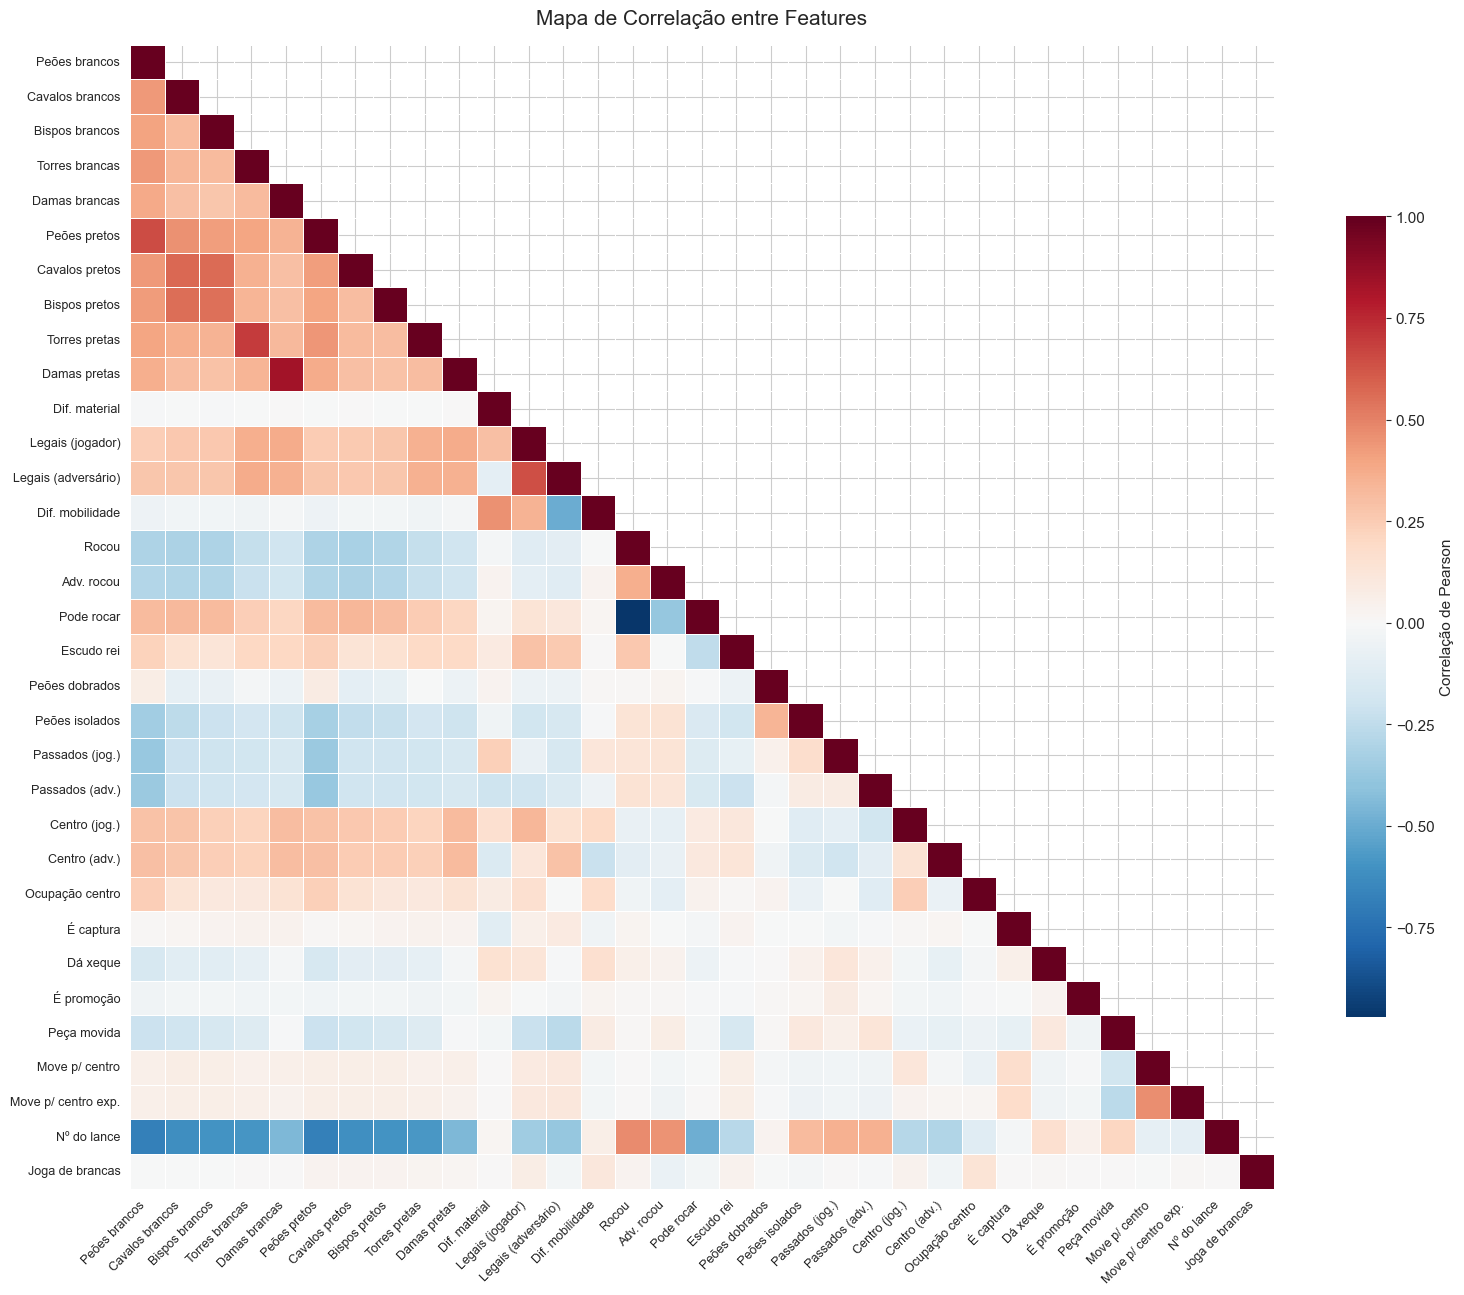


Pares com |correlação| > 0.7:
  Rocou                      ↔  Pode rocar                 r = -0.970
  Damas brancas              ↔  Damas pretas               r = +0.836


In [7]:
FEATURE_TRANSLATION = {
    "white_pawns": "Peões brancos", "white_knights": "Cavalos brancos",
    "white_bishops": "Bispos brancos", "white_rooks": "Torres brancas",
    "white_queens": "Damas brancas", "black_pawns": "Peões pretos",
    "black_knights": "Cavalos pretos", "black_bishops": "Bispos pretos",
    "black_rooks": "Torres pretas", "black_queens": "Damas pretas",
    "material_diff": "Dif. material", "legal_moves_player": "Legais (jogador)",
    "legal_moves_opponent": "Legais (adversário)", "mobility_diff": "Dif. mobilidade",
    "player_castled": "Rocou", "opponent_castled": "Adv. rocou",
    "player_can_castle": "Pode rocar", "king_pawn_shield": "Escudo rei",
    "player_doubled_pawns": "Peões dobrados", "player_isolated_pawns": "Peões isolados",
    "player_passed_pawns": "Passados (jog.)", "opponent_passed_pawns": "Passados (adv.)",
    "player_center_control": "Centro (jog.)", "opponent_center_control": "Centro (adv.)",
    "player_center_occupation": "Ocupação centro", "is_capture": "É captura",
    "is_check": "Dá xeque", "is_promotion": "É promoção",
    "moved_piece": "Peça movida", "move_to_center": "Move p/ centro",
    "move_to_extended_center": "Move p/ centro exp.",
    "move_number": "Nº do lance", "is_white": "Joga de brancas",
}

corr = df_features[feature_cols].corr()

labels_pt = [FEATURE_TRANSLATION.get(c, c) for c in feature_cols]

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap="RdBu_r", center=0,
    xticklabels=labels_pt, yticklabels=labels_pt,
    annot=False, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlação de Pearson"},
    ax=ax,
)
ax.set_title("Mapa de Correlação entre Features", fontsize=15, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = abs(corr.iloc[i, j])
        if r > 0.7:
            high_corr.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))

if high_corr:
    print("\nPares com |correlação| > 0.7:")
    for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {FEATURE_TRANSLATION.get(a, a):25s}  ↔  {FEATURE_TRANSLATION.get(b, b):25s}  r = {r:+.3f}")
else:
    print("\nNenhum par de features com |correlação| > 0.7.")

---

## 5. Treino dos Modelos

### Split dos dados

O dataset foi dividido em 70/15/15 (treino/validação/teste) com **estratificação** para manter a proporção bom/ruim em cada split. O conjunto de teste só é usado uma vez, na avaliação final.

### Tratamento do desbalanceamento

A classe "ruim" representa ~15.6% do dataset (ratio 5.4:1). Para mitigar o viés para a classe majoritária, usamos `class_weight="balanced"` em ambos os modelos — isso aumenta o peso da perda para exemplos da classe minoritária proporcionalmente à sua frequência.

### Modelos

| Modelo | Justificativa |
|--------|---------------|
| **Decision Tree** | Obrigatório pela disciplina. Permite extrair regras interpretáveis no domínio de xadrez. |
| **Random Forest** | Ensemble de árvores que reduz variância e tipicamente melhora generalização. Permite comparação direta com a árvore única. |

### Tuning

Ambos os modelos foram tunados via `GridSearchCV` com 5 folds e métrica F1 (classe "ruim").

In [8]:
X = df_features.drop(columns=["label"])
y = (df_features["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED
)

split_info = pd.read_csv(DATA_DIR / "models" / "split_info.csv")
print("Distribuição dos splits:\n")
print(split_info.to_string(index=False))
print(f"\nProporção ruim em cada split:")
for _, row in split_info.iterrows():
    pct = row["ruim"] / row["total"] * 100
    print(f"  {row['split']:6s}: {pct:.1f}%")

Distribuição dos splits:

split  total   bom  ruim
train  76546 64574 11972
  val  16350 13793  2557
 test  16394 13830  2564

Proporção ruim em cada split:
  train : 15.6%
  val   : 15.6%
  test  : 15.6%


In [9]:
dt = joblib.load(DATA_DIR / "models" / "decision_tree.joblib")
rf = joblib.load(DATA_DIR / "models" / "random_forest.joblib")

with open(DATA_DIR / "models" / "feature_names.json") as f:
    feature_names = json.load(f)

print("=" * 55)
print("  Decision Tree — Melhores hiperparâmetros")
print("=" * 55)
print(f"  criterion      : {dt.criterion}")
print(f"  max_depth      : {dt.max_depth}")
print(f"  min_samples_leaf: {dt.min_samples_leaf}")
print(f"  class_weight   : {dt.class_weight}")

print(f"\n{'=' * 55}")
print("  Random Forest — Melhores hiperparâmetros")
print("=" * 55)
print(f"  n_estimators    : {rf.n_estimators}")
print(f"  max_depth       : {rf.max_depth}")
print(f"  min_samples_leaf: {rf.min_samples_leaf}")
print(f"  class_weight    : {rf.class_weight}")

  Decision Tree — Melhores hiperparâmetros
  criterion      : gini
  max_depth      : 7
  min_samples_leaf: 20
  class_weight   : balanced

  Random Forest — Melhores hiperparâmetros
  n_estimators    : 200
  max_depth       : 10
  min_samples_leaf: 5
  class_weight    : balanced


---

## 6. Avaliação

A avaliação é feita no **conjunto de teste** (16,394 lances), que não foi usado em nenhuma etapa de treino ou tuning.

A classe "ruim" (positiva) é a mais importante: o objetivo do classificador é **detectar erros**. Um modelo que classifica tudo como "bom" teria ~84% de accuracy mas seria completamente inútil. Por isso, enfatizamos:

- **Recall (ruim):** dos lances realmente ruins, quantos o modelo detectou?
- **F1 (ruim):** equilíbrio entre precision e recall da classe minoritária
- **ROC-AUC:** capacidade discriminativa independente do threshold

In [10]:
print("=" * 60)
print("  DECISION TREE — Relatório de Classificação (teste)")
print("=" * 60)
y_pred_dt = dt.predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=["bom", "ruim"]))

print("=" * 60)
print("  RANDOM FOREST — Relatório de Classificação (teste)")
print("=" * 60)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=["bom", "ruim"]))

  DECISION TREE — Relatório de Classificação (teste)
              precision    recall  f1-score   support

         bom       0.89      0.62      0.73     13830
        ruim       0.23      0.60      0.33      2564

    accuracy                           0.62     16394
   macro avg       0.56      0.61      0.53     16394
weighted avg       0.79      0.62      0.67     16394

  RANDOM FOREST — Relatório de Classificação (teste)
              precision    recall  f1-score   support

         bom       0.89      0.71      0.79     13830
        ruim       0.26      0.55      0.35      2564

    accuracy                           0.68     16394
   macro avg       0.58      0.63      0.57     16394
weighted avg       0.80      0.68      0.72     16394



In [11]:
results = pd.read_csv(DATA_DIR / "models" / "results.csv")

print("Tabela comparativa — Conjunto de teste:\n")
display_df = results.rename(columns={
    "model": "Modelo", "accuracy": "Accuracy",
    "f1_bom": "F1 (bom)", "f1_ruim": "F1 (ruim)",
    "roc_auc": "ROC-AUC", "recall_ruim": "Recall (ruim)",
    "precision_ruim": "Precision (ruim)",
})
display_df

Tabela comparativa — Conjunto de teste:



,Modelo,Accuracy,F1 (bom),F1 (ruim),ROC-AUC,Recall (ruim),Precision (ruim)
0,Decision Tree,0.6176,0.7328,0.3280,0.6487,0.5967,0.2262
1,Random Forest,0.6827,0.7899,0.3525,0.6837,0.5523,0.2589


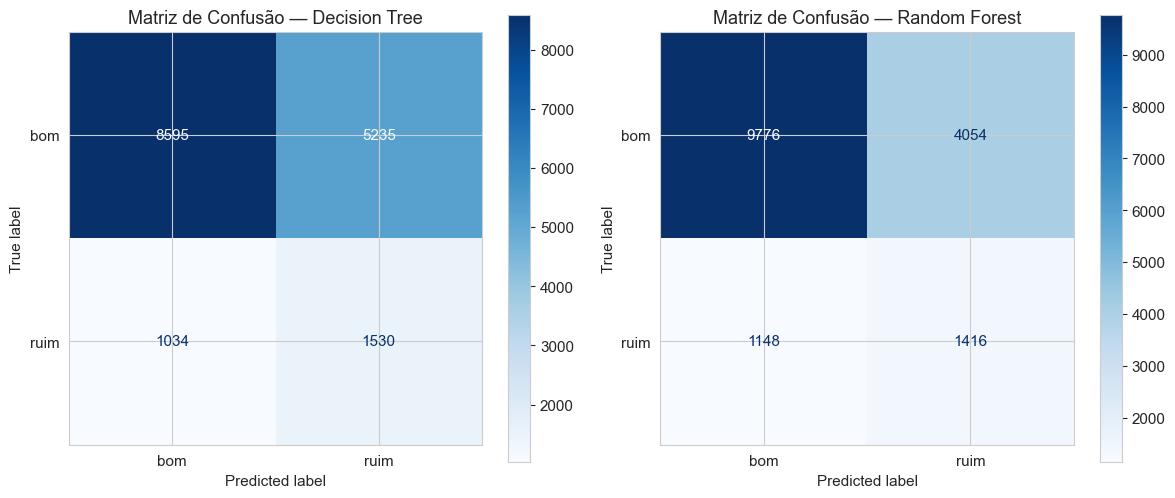

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in [
    (axes[0], dt, "Decision Tree"),
    (axes[1], rf, "Random Forest"),
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["bom", "ruim"],
        cmap="Blues", ax=ax, values_format="d",
    )
    ax.set_title(f"Matriz de Confusão — {name}", fontsize=13)

plt.tight_layout()
plt.show()

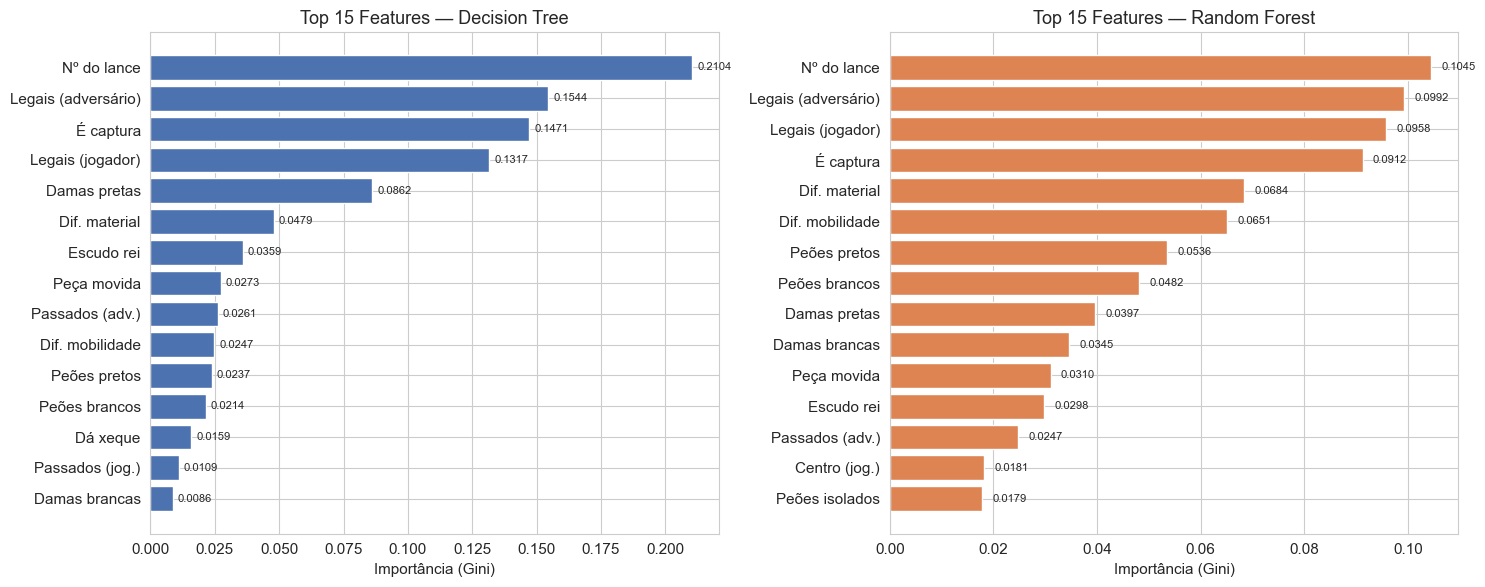

In [13]:
def plot_fi(model, feature_names, title, color, ax, top_n=15):
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:top_n]
    labels = [FEATURE_TRANSLATION.get(feature_names[i], feature_names[i]) for i in idx]
    values = imp[idx]

    bars = ax.barh(range(top_n), values, color=color)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("Importância (Gini)")
    ax.set_title(title, fontsize=13)

    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_fi(dt, feature_names, "Top 15 Features — Decision Tree", "#4C72B0", axes[0])
plot_fi(rf, feature_names, "Top 15 Features — Random Forest", "#DD8452", axes[1])
plt.tight_layout()
plt.show()

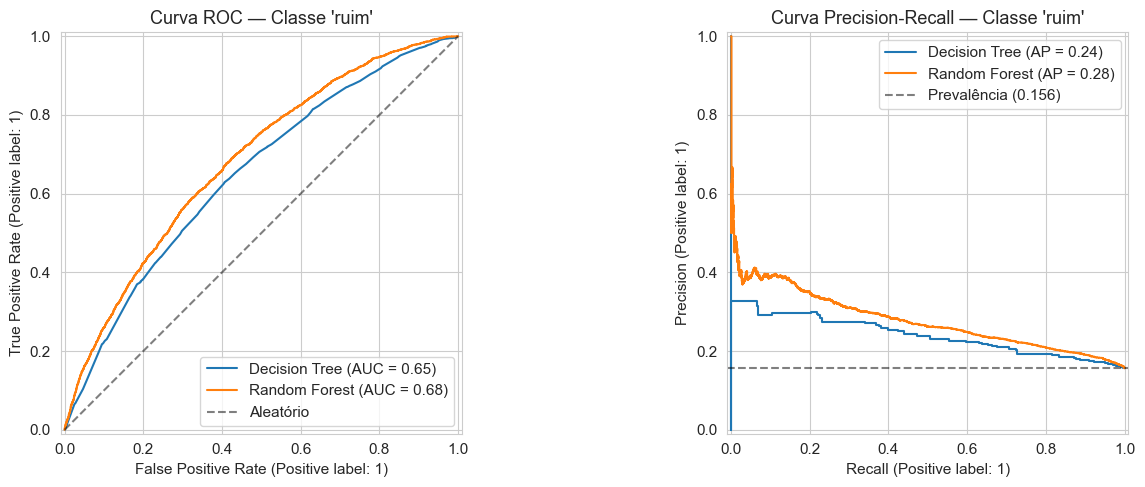

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax = axes[0]
RocCurveDisplay.from_estimator(dt, X_test, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
ax.set_title("Curva ROC — Classe 'ruim'", fontsize=13)
ax.legend()

# Curva Precision-Recall
ax = axes[1]
PrecisionRecallDisplay.from_estimator(dt, X_test, y_test, ax=ax, name="Decision Tree")
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, ax=ax, name="Random Forest")
prevalence = y_test.mean()
ax.axhline(y=prevalence, color="k", linestyle="--", alpha=0.5, label=f"Prevalência ({prevalence:.3f})")
ax.set_title("Curva Precision-Recall — Classe 'ruim'", fontsize=13)
ax.legend()

plt.tight_layout()
plt.show()

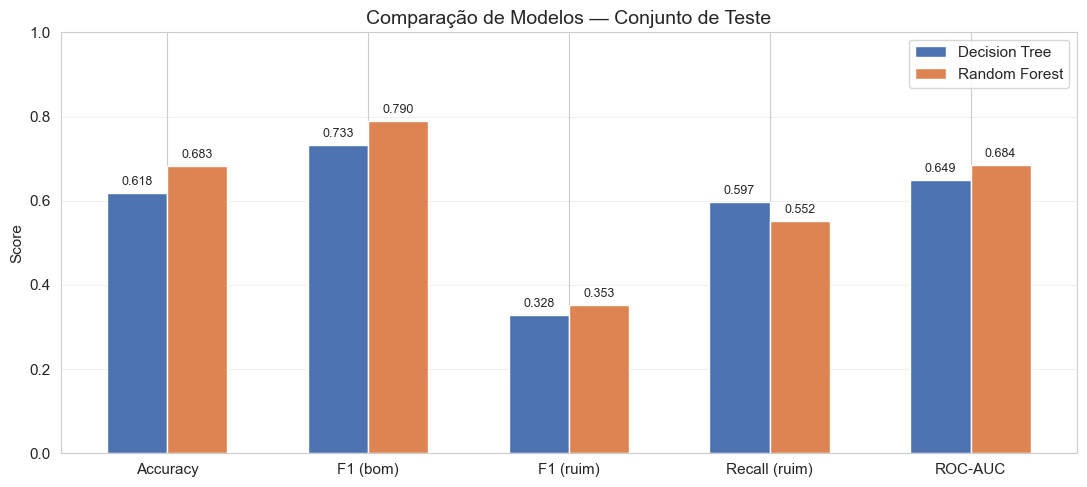

In [15]:
metrics_data = {}
for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    yp = model.predict(X_test)
    yproba = model.predict_proba(X_test)[:, 1]
    metrics_data[name] = {
        "Accuracy": accuracy_score(y_test, yp),
        "F1 (bom)": f1_score(y_test, yp, pos_label=0),
        "F1 (ruim)": f1_score(y_test, yp, pos_label=1),
        "Recall (ruim)": (yp[y_test == 1] == 1).mean(),
        "ROC-AUC": roc_auc_score(y_test, yproba),
    }

metric_names = list(next(iter(metrics_data.values())).keys())
x = np.arange(len(metric_names))
width = 0.30

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model_name, vals) in enumerate(metrics_data.items()):
    values = [vals[m] for m in metric_names]
    bars = ax.bar(x + i * width, values, width, label=model_name,
                  color=["#4C72B0", "#DD8452"][i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Comparação de Modelos — Conjunto de Teste", fontsize=14)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## 7. Exemplos Interpretados

### Regras da Árvore de Decisão

A árvore treinada aprende regras "se-então" que podem ser traduzidas para conceitos de xadrez. A primeira decisão da árvore é se o lance é uma **captura** — lances de captura e lances quietos são avaliados por caminhos diferentes.

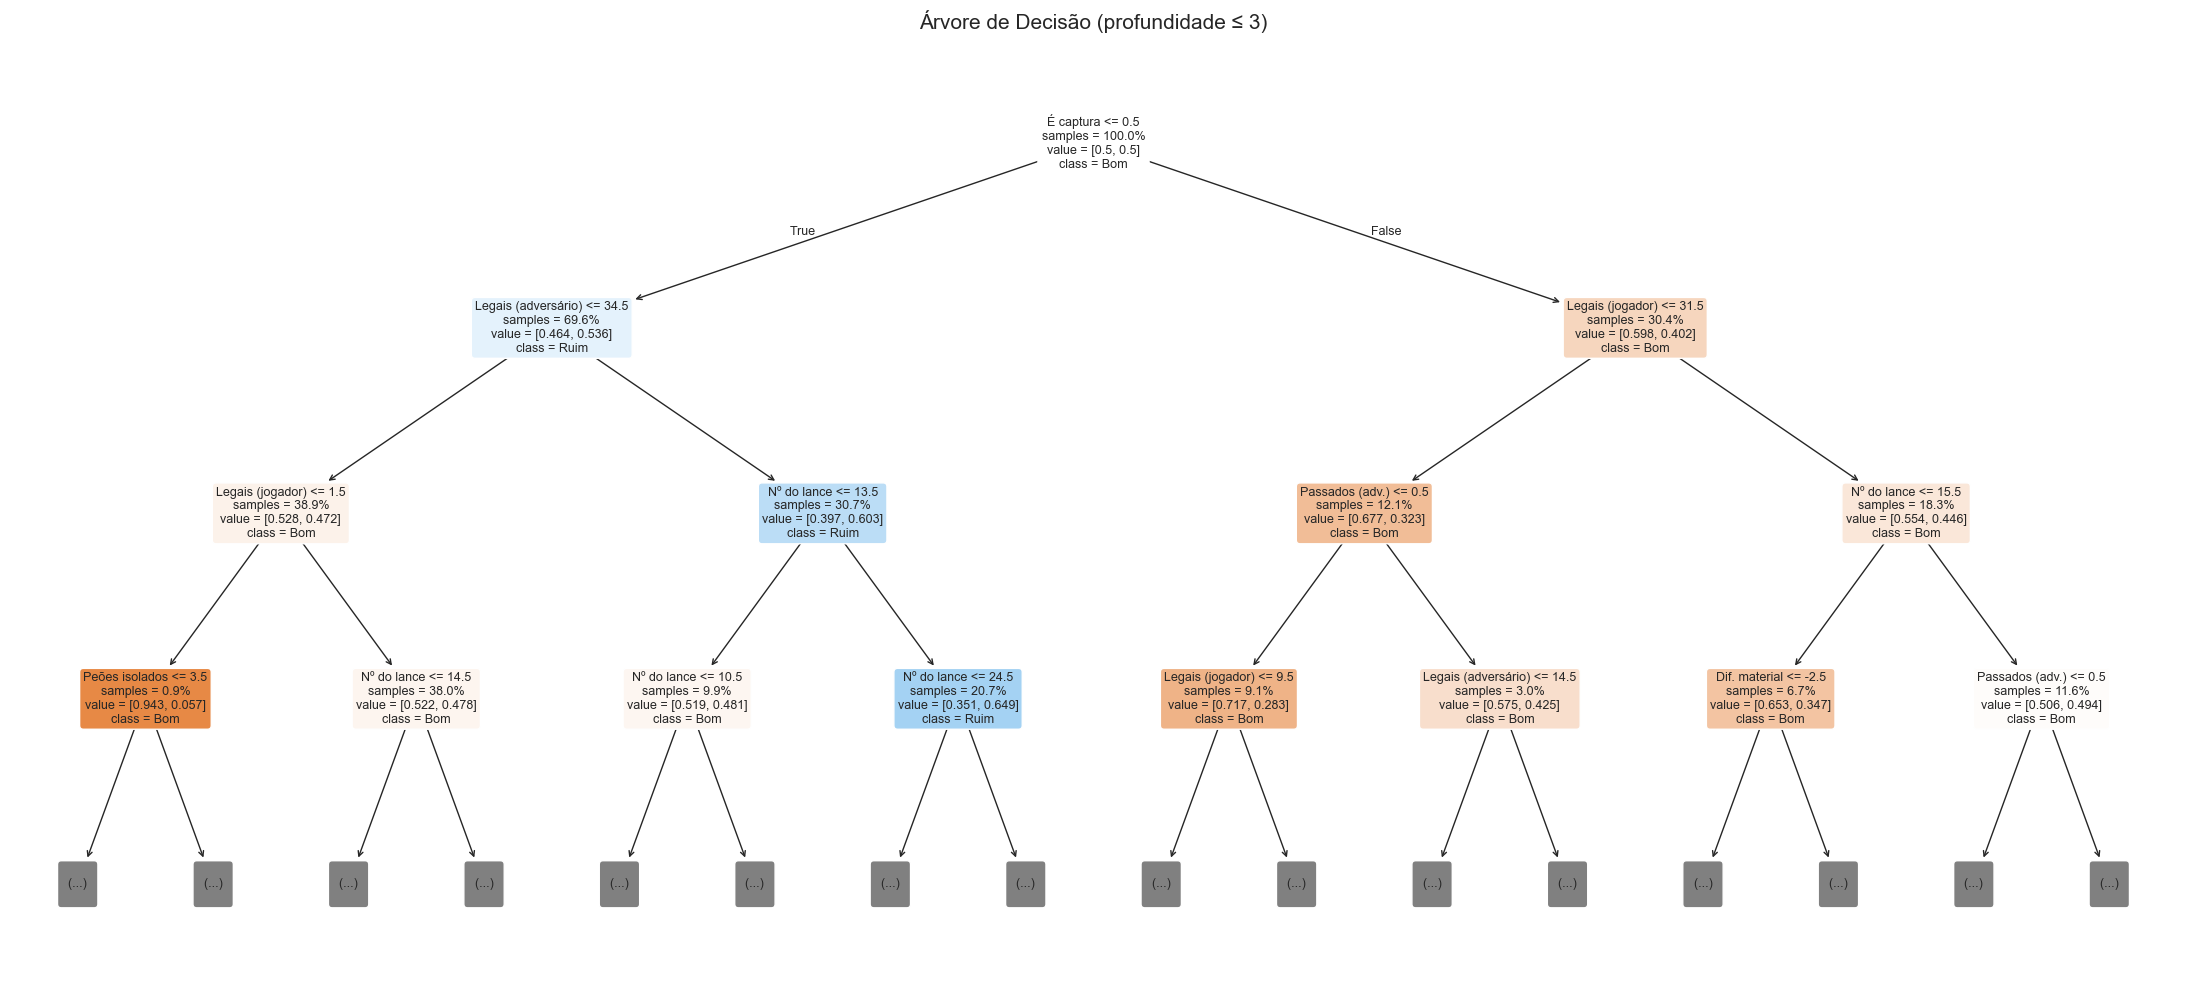

In [16]:
fig, ax = plt.subplots(figsize=(22, 10))

translated_names = [FEATURE_TRANSLATION.get(f, f) for f in feature_names]

plot_tree(
    dt, feature_names=translated_names,
    class_names=["Bom", "Ruim"],
    filled=True, rounded=True,
    max_depth=3, fontsize=9, ax=ax,
    impurity=False, proportion=True,
)
ax.set_title("Árvore de Decisão (profundidade ≤ 3)", fontsize=15, pad=15)
plt.tight_layout()
plt.show()

In [17]:
rules_path = DATA_DIR / "evaluation" / "decision_tree_rules_chess.txt"
rules_text = rules_path.read_text()

print(rules_text[:3000])
if len(rules_text) > 3000:
    print("\n... (regras continuam)")

═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - "Diferença material <= -3.0": jogador com ≥3 pontos a menos
  - "Lances legais (jogador)": mobilidade/atividade das peças
  - "É captura": o lance captura uma peça adversária
  - "Número do lance": fase da partida (abertura/meio-jogo/final)
  - "Peça movida": 1=Peão, 2=Cavalo, 3=Bispo, 4=Torre, 5=Dama, 6=Rei
  - "Escudo de peões do rei": peões protegendo o rei (0–3)

═══════════════════════════════════════════════════════════

|--- É captura <= 0.50
|   |--- Lances legais (adversário) <= 34.50
|   |   |--- Lances legais (jogador) <= 1.50
|   |   |   |--- Peões isolados <= 3.50
|   |   |   |   |--- Joga de brancas <= 0.50
|   |   |   |   |   |--- Bispos brancos <= 0.50
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- Bispos brancos >  0.50
|   |   |   |   |   |   |--- tr

### Interpretação das regras principais

As regras revelam padrões coerentes com a teoria de xadrez:

1. **Capturas vs. lances quietos:** a árvore separa primeiro capturas de lances quietos. Capturas têm dinâmicas diferentes (troca de material) e padrões de erro distintos.

2. **Mobilidade do adversário:** se o adversário tem muitos lances legais (> 34), é sinal de posição aberta onde é mais fácil errar — a árvore reconhece que nesses contextos lances "quietos" merecem mais escrutínio.

3. **Fase da partida:** o número do lance é um dos melhores preditores. Erros são mais frequentes em transições (lance 10–15 e 24+), quando a complexidade posicional muda.

4. **Presença de damas:** posições com damas no tabuleiro são mais táticas e propensas a erros.

### Análise de erros

Abaixo, exemplos concretos de **falsos positivos** (modelo previu "ruim" mas o lance é bom) e **falsos negativos** (modelo previu "bom" mas o lance é ruim).

In [18]:
df_fp = pd.read_csv(DATA_DIR / "evaluation" / "error_analysis_fp.csv")
df_fn = pd.read_csv(DATA_DIR / "evaluation" / "error_analysis_fn.csv")

PIECE_NAMES = {1: "Peão", 2: "Cavalo", 3: "Bispo", 4: "Torre", 5: "Dama", 6: "Rei"}

def show_examples(df, error_type, model_name, n=5):
    subset = df[df["model"] == model_name].head(n)
    tipo = "FALSOS POSITIVOS" if error_type == "FP" else "FALSOS NEGATIVOS"
    desc = ('modelo disse "ruim", mas o lance é bom' if error_type == "FP"
            else 'modelo disse "bom", mas o lance é ruim')

    print(f"\n{'='*65}")
    print(f"  {tipo} — {model_name}")
    print(f"  ({desc})")
    print(f"{'='*65}")

    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\n  {error_type}-{i}:")
        print(f"    Partida : {row['game_site']}")
        print(f"    Lance   : {row['move_san']} (#{int(row['move_number'])}, {row['color']})")
        print(f"    Delta   : {row['delta_cp']} cp")
        print(f"    FEN     : {row['fen_before']}")

        feats = str(row.get("top_features", "")).split("; ")
        print(f"    Features: ", end="")
        print("; ".join(
            f"{FEATURE_TRANSLATION.get(f.split('=')[0], f.split('=')[0])}={f.split('=')[1]}"
            for f in feats if "=" in f
        ))

show_examples(df_fp, "FP", "Decision Tree")
show_examples(df_fn, "FN", "Decision Tree")


  FALSOS POSITIVOS — Decision Tree
  (modelo disse "ruim", mas o lance é bom)

  FP-1:
    Partida : https://lichess.org/YVwQkEzq
    Lance   : Kh2 (#31, white)
    Delta   : -15 cp
    FEN     : 6k1/pp3p2/2p5/6p1/1PP5/PbQ1P1B1/5PB1/3q2K1 w - - 5 31
    Features: Nº do lance=31; Legais (adversário)=0; É captura=0; Legais (jogador)=3; Damas pretas=1

  FP-2:
    Partida : https://lichess.org/hM8rqjDj
    Lance   : Rd8 (#35, black)
    Delta   : -9 cp
    FEN     : 5r1k/1p4pp/p1p5/3q4/1P3bP1/5P2/1B2Q2P/6K1 b - - 5 35
    Features: Nº do lance=35; Legais (adversário)=33; É captura=0; Legais (jogador)=49; Damas pretas=1

  FP-3:
    Partida : https://lichess.org/ts3bvNer
    Lance   : Kf2 (#32, white)
    Delta   : -15 cp
    FEN     : 2b3k1/5p1p/6p1/3p4/P1pP4/8/6PP/1B4K1 w - - 1 32
    Features: Nº do lance=32; Legais (adversário)=16; É captura=0; Legais (jogador)=14; Damas pretas=0

  FP-4:
    Partida : https://lichess.org/kLZKCPbL
    Lance   : Bg6 (#29, black)
    Delta   : -18 cp
  

### Discussão dos erros

**Falsos positivos típicos** (modelo diz "ruim" mas o lance é bom):
- Lances quietos em posições com alta mobilidade do adversário — a árvore "desconfia" de lances passivos nessas situações, mas o lance pode ser perfeitamente adequado.
- Posições no final do meio-jogo (lance 28+) onde a árvore tem viés por associar fases tardias com erros.

**Falsos negativos típicos** (modelo diz "bom" mas o lance é ruim):
- Erros táticos sutis: capturas que parecem normais pelas features posicionais mas perdem material por razões concretas (cravadas, raio-x, contra-ataques).
- Lances em posições com avaliação estável (mobilidade equilibrada) onde o erro é específico da sequência de lances — impossível de capturar sem features táticas.

**Limitação fundamental:** as 33 features posicionais capturam o "ambiente" da posição mas não as **táticas concretas** — um lance pode ser ruim por perder um cavalo cravado, mas as features não incluem detecção de cravadas.

---

## 8. Conclusões e Trabalhos Futuros

### Resultados

| Aspecto | Conclusão |
|---------|-----------|  
| **Melhor modelo** | Random Forest — superior em accuracy (0.68 vs 0.62), F1-ruim (0.35 vs 0.33) e AUC (0.68 vs 0.65) |
| **Recall (ruim)** | DT: 59.7%, RF: 55.2% — a DT detecta mais erros ao custo de mais falsos positivos |
| **Features mais importantes** | Nº do lance, mobilidade (jogador e adversário), se é captura, diferença material |
| **Interpretabilidade** | As regras da DT fazem sentido no domínio: capturas, fases do jogo e mobilidade são critérios coerentes com a teoria de xadrez |

O F1 da classe "ruim" é modesto (~0.35), o que é esperado dado:
1. **Desbalanceamento 5.4:1** — a classe minoritária é inherentemente difícil de prever
2. **Features posicionais simples** — não capturam padrões táticos concretos
3. **Natureza do problema** — prever erros humanos é fundamentalmente difícil com features estáticas

### Limitações

- **Dataset limitado** a uma faixa de rating (1400–1700 Lichess) e período (janeiro 2015). Resultados podem não generalizar para outros níveis.
- **Features simples** — não capturam ameaças táticas (cravadas, raio-x, ataques duplos, peças indefesas). Estes são os motivos reais da maioria dos erros nesta faixa de rating.
- **Dependência do Stockfish** — a qualidade dos rótulos depende da profundidade de análise (depth 15). Lances avaliados incorretamente pelo engine introduzem ruído.
- **Classificação binária** — a distinção bom/ruim é simplista. Nuances como "imprecisão leve" vs. "blunder grave" são perdidas.

### Trabalhos futuros

1. **Features táticas:** detectar cravadas, raio-x, peças indefesas, ameaças de mate — potencialmente o maior ganho de performance.
2. **Foco por fase:** modelos separados para abertura, meio-jogo e final.
3. **Classificação multiclasse:** brilhante / bom / imprecisão / erro / blunder (5 classes, como no Lichess).
4. **Modelos mais sofisticados:** MLP ou gradient boosting com features táticas.
5. **Aplicação prática:** acoplar o classificador a um módulo que sugere ao jogador revisar posições onde prevê erro.